# Meta-labeling contextual *greedy*: resumen narrativo y evidencia visual

**Alcance:** consolidar la campaña *greedy* `contextual_metalabeling/20260513T182131Z` (panel nominal **30** ramas: 5 símbolos × 3 métodos × 2 familias) donde la
pregunta es si **añadir bloques de fuentes contextuales** (`derivatives_futures`, `microstructure`, `onchain`,
`sentiment`, `attention`) sobre la raíz `core_only` mejora el Sharpe agregado del *meta-labeling* de segunda
capa anclado en el *shortlist* del Experimento 1.5 (`03_evidencia_shortlist_meta_labeling.ipynb`, complemento fold-level en `04_evidencia_robustez_fold_shortlist_meta_labeling.ipynb`). La rama `BTCUSDT`/`fixed_horizon`/`lstm` se materializó tras
actualizar la shortlist congelada al artefacto reparado (20260528) y reanudar la campaña con `--resume`.
La decisión se audita celda a celda (`winner_subset`, `winner_depth`, `winner_verdict`) bajo el mismo contrato de veredictos `alpha` / `beta` / `gamma` del Exp 2,
con la diferencia de que aquí el modelo evaluado es el *meta* binario (ejecutar / filtrar) y no el primario.

**Insumos en disco (campaña posterior al *fix* del *bundle* de aceptación supervisada):**

- `reports/validation/experiments/contextual_metalabeling/20260513T182131Z/metalabeling_greedy_summary.json`
- `reports/validation/experiments/contextual_metalabeling/20260513T182131Z/<symbol>/<method>/<family>/none/greedy_tree.json`

**Productos:** tablas CSV y figuras PNG bajo `reports/figures/exp_synthesis/metalabeling_contextual_greedy/` (lista exhaustiva en la sección 8).

In [26]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.options.display.max_columns = 60
pd.options.display.max_rows = 200
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

COLUMNAS_ES = {
    'symbol': 'simbolo',
    'method': 'metodo',
    'family': 'familia',
    'cell_key': 'clave_celda',
    'block': 'bloque',
    'branch_complete': 'rama_completa',
    'winner_subset': 'subset_ganador',
    'winner_depth': 'profundidad_ganador',
    'winner_verdict': 'veredicto_ganador',
    'winner_aggregate_sharpe': 'sharpe_agregado_ganador',
    'core_aggregate_sharpe': 'sharpe_agregado_core',
    'delta_winner_minus_core': 'delta_ganador_menos_core',
    'aggregate_sharpe': 'sharpe_agregado',
    'verdict': 'veredicto',
    'sharpe': 'sharpe',
    'n_branches': 'n_ramas',
    'n_evaluations': 'n_evaluaciones',
    'n_alpha': 'n_alpha',
    'n_beta': 'n_beta',
    'n_gamma': 'n_gamma',
    'n_folds': 'n_folds',
    'median_delta_sharpe': 'mediana_delta_sharpe',
    'median_wilcoxon_p': 'mediana_p_wilcoxon',
    'median_aggregate_sharpe': 'mediana_sharpe_agregado',
    'median_mean_filter_ratio': 'mediana_tasa_filtrado',
    'wilcoxon_p_value': 'p_wilcoxon',
    'mean_filter_ratio': 'tasa_filtrado_media',
    'mean_filter_ratio_median': 'tasa_filtrado_mediana',
    'mean_filter_ratio_p10': 'tasa_filtrado_p10',
    'mean_filter_ratio_p90': 'tasa_filtrado_p90',
    'mean_meta_executed_ratio': 'tasa_ejecutadas_meta_media',
    'mean_meta_executed_ratio_median': 'tasa_ejecutadas_meta_mediana',
    'mean_delta_sharpe': 'delta_sharpe_medio',
    'mean_delta_sharpe_median': 'delta_sharpe_medio_mediana',
    'mean_delta_sharpe_mean': 'delta_sharpe_medio_media',
    'mean_delta_sharpe_p10': 'delta_sharpe_medio_p10',
    'mean_delta_sharpe_p90': 'delta_sharpe_medio_p90',
    'core_mean_filter_ratio': 'tasa_filtrado_media_core',
    'core_mean_meta_executed_ratio': 'tasa_ejecutadas_meta_media_core',
    'core_mean_delta_sharpe': 'delta_sharpe_medio_core',
    'core_sharpe_median': 'sharpe_core_mediana',
    'core_sharpe_mean': 'sharpe_core_media',
    'winner_sharpe_median': 'sharpe_ganador_mediana',
    'winner_sharpe_mean': 'sharpe_ganador_media',
    'delta_median': 'delta_mediana',
    'delta_mean': 'delta_media',
    'n_branches_with_delta_gt0': 'n_ramas_delta_positivo',
    'n_branches_with_delta_eq0': 'n_ramas_delta_cero',
    'median_sharpe': 'mediana_sharpe',
    'mean_sharpe': 'media_sharpe',
    'std_sharpe': 'desv_std_sharpe',
    'p10_sharpe': 'p10_sharpe',
    'p90_sharpe': 'p90_sharpe',
    'n_branches_complete': 'n_ramas_completas',
    'n_symbols': 'n_simbolos',
    'n_methods': 'n_metodos',
    'n_families': 'n_familias',
    'n_winners_core_only': 'n_ganadores_core_only',
    'n_winners_context_block': 'n_ganadores_bloque_contextual',
}


def _nombre_columna_es(nombre: str) -> str:
    return COLUMNAS_ES.get(nombre, nombre)


def a_es(frame):
    if isinstance(frame, pd.Series):
        frame = frame.to_frame(name=frame.name)
    vista = frame.copy()
    vista.columns = [_nombre_columna_es(str(col)) for col in vista.columns]
    if vista.index.name:
        vista.index.name = _nombre_columna_es(str(vista.index.name))
    if isinstance(vista.index, pd.MultiIndex):
        vista.index = vista.index.set_names([
            _nombre_columna_es(str(name)) if name is not None else name
            for name in vista.index.names
        ])
    return vista


def display_es(frame) -> None:
    display(a_es(frame))


def locate_repo_root(start: Path | None = None) -> Path:
    root = (start or Path.cwd()).resolve()
    while root != root.parent and not (root / 'src').exists():
        root = root.parent
    if not (root / 'src').exists():
        raise FileNotFoundError('No se encontró la raíz del repo (carpeta src/).')
    return root


ROOT = locate_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
EVIDENCE_DIR = ROOT / 'evidence_utils'
if str(EVIDENCE_DIR) not in sys.path:
    sys.path.insert(0, str(EVIDENCE_DIR))

from phase_summaries import (
    METALABELING_GREEDY_STAMP_DEFAULT,
    METALABELING_CONTEXTUAL_BLOCKS,
    collect_meta_shortlist_cell_deflators,
    collect_meta_greedy_cell_deflators,
    load_meta_greedy_winner_oos_from_row,
    load_metalabeling_greedy_winners,
    load_metalabeling_contextual_nodes,
    load_metalabeling_winner_fold_sharpes,
)

REPORT_ROOT = ROOT / 'reports' / 'validation' / 'experiments'
FIG_DIR = ROOT / 'reports' / 'figures' / 'exp_synthesis' / 'metalabeling_contextual_greedy'
FIG_DIR.mkdir(parents=True, exist_ok=True)

BRANCH_STAMP = METALABELING_GREEDY_STAMP_DEFAULT

## 1. Completitud de la campaña y reparto por familia/método

Verificación de que las ramas planificadas fueron evaluadas y conteo por dimensiones canónicas (familia, símbolo, método de etiquetado). Tras el backfill de `BTCUSDT`/`fixed_horizon`/`lstm`, el panel nominal es **30** ramas.

In [27]:
winners = load_metalabeling_greedy_winners(REPORT_ROOT, branch_stamp=BRANCH_STAMP)
a_es(winners).to_csv(FIG_DIR / 'metalabeling_winners_raw.csv', index=False)

completeness = {
    'n_branches': int(len(winners)),
    'n_branches_complete': int(winners['branch_complete'].fillna(False).astype(bool).sum()),
    'n_symbols': int(winners['symbol'].nunique()),
    'n_methods': int(winners['method'].nunique()),
    'n_families': int(winners['family'].nunique()),
    'n_winners_core_only': int((winners['winner_subset'] == 'core_only').sum()),
    'n_winners_context_block': int((winners['winner_subset'] != 'core_only').sum()),
}
print('Completitud de campaña')
display_es(pd.DataFrame([completeness]).T.rename(columns={0: 'valor'}))

by_family = winners['family'].value_counts().sort_index().to_frame('n_branches')
by_method = winners['method'].value_counts().sort_index().to_frame('n_branches')
by_symbol = winners['symbol'].value_counts().sort_index().to_frame('n_branches')
a_es(by_family).to_csv(FIG_DIR / 'metalabeling_branches_by_family.csv')
a_es(by_method).to_csv(FIG_DIR / 'metalabeling_branches_by_method.csv')
a_es(by_symbol).to_csv(FIG_DIR / 'metalabeling_branches_by_symbol.csv')
print('Ramas por familia/método/símbolo')
display_es(by_family.T)
display_es(by_method.T)
display_es(by_symbol.T)

Completitud de campaña


,valor
n_branches,30
n_branches_complete,30
n_symbols,5
n_methods,3
n_families,2
n_winners_core_only,29
n_winners_context_block,1


Ramas por familia/método/símbolo


,lstm,xgboost
n_branches,15,15


,fixed_horizon,trend_scanning,triple_barrier
n_branches,10,10,10


,BNBUSDT,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT
n_branches,6,6,6,6,6


## 2. Decisión del *greedy*: subset ganador, profundidad y veredicto

Resumen de la pregunta central del experimento: **¿cuánto *greedy* queda activado por rama y con qué veredicto?**

- `winner_subset` -> bloque ganador (`core_only` significa que el *greedy* del *meta* no expandió).
- `winner_depth` -> profundidad alcanzada (0 = nodo raíz `core_only`).
- `winner_verdict` -> tipo de aceptación (`root` para `core_only`, `beta` para expansión por mejora positiva
  pero conservadora, `gamma` para expansión por mejora amplia).

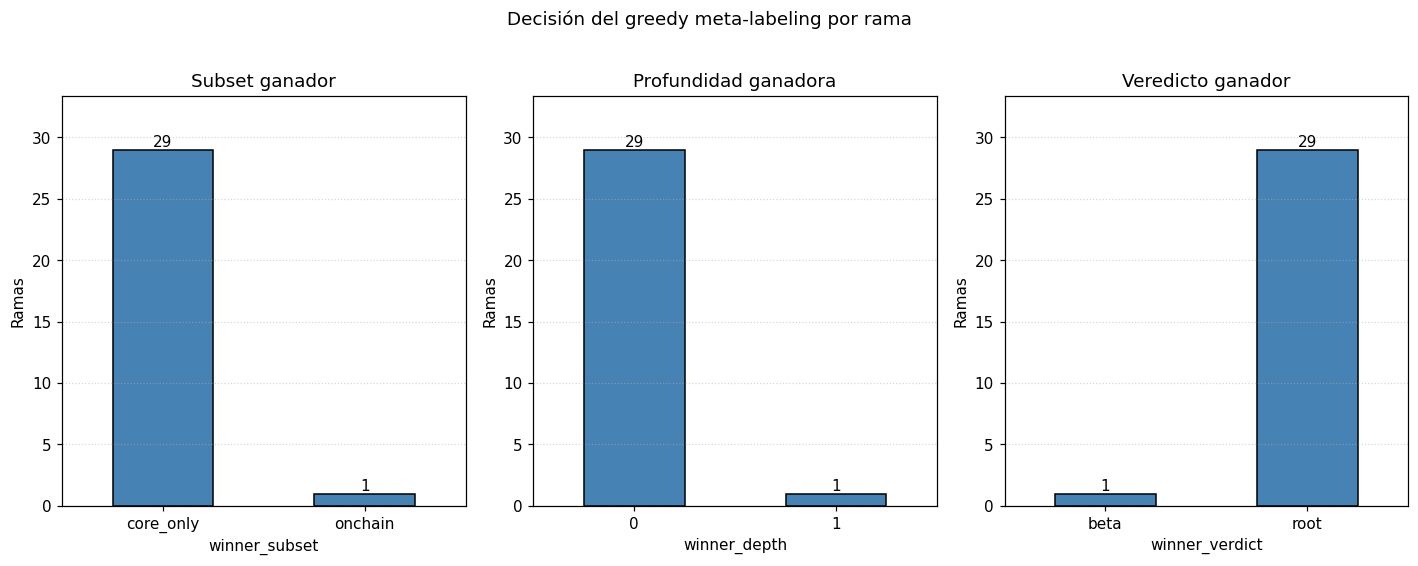

Conteos


,n_ramas
subset_ganador,
core_only,29
onchain,1


,n_ramas
profundidad_ganador,
0,29
1,1


,n_ramas
veredicto_ganador,
beta,1
root,29


In [28]:
subset_counts = winners['winner_subset'].value_counts().sort_index()
depth_counts = winners['winner_depth'].astype('Int64').value_counts().sort_index()
verdict_counts = winners['winner_verdict'].value_counts().sort_index()
a_es(subset_counts.to_frame('n_branches')).to_csv(FIG_DIR / 'metalabeling_winner_subset_counts.csv')
a_es(depth_counts.to_frame('n_branches')).to_csv(FIG_DIR / 'metalabeling_winner_depth_counts.csv')
a_es(verdict_counts.to_frame('n_branches')).to_csv(FIG_DIR / 'metalabeling_winner_verdict_counts.csv')

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, series, title in zip(
    axes,
    [subset_counts, depth_counts, verdict_counts],
    ['Subset ganador', 'Profundidad ganadora', 'Veredicto ganador'],
):
    series.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel('Ramas')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ymax = max(float(series.max()), 1.0)
    ax.set_ylim(0, ymax * 1.15)
    ax.tick_params(axis='x', rotation=0)
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        label.set_ha('center')
    for p in ax.patches:
        ax.annotate(
            str(int(p.get_height())),
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=10,
            clip_on=False,
        )
fig.suptitle('Decisión del greedy meta-labeling por rama', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'metalabeling_winner_decision_bars.png')
plt.show()

print('Conteos')
display_es(subset_counts.to_frame('n_branches'))
display_es(depth_counts.to_frame('n_branches'))
display_es(verdict_counts.to_frame('n_branches'))

## 3. Aportación marginal por bloque contextual

Para cada bloque contextual probado como hijo directo del nodo `core_only` se reportan:

- Conteo de veredictos `alpha`/`beta`/`gamma` sobre todas las ramas (1 evaluación por rama y bloque).
- Mediana de `delta_sharpe` pareado por *fold* del *meta* frente al *meta* `core_only`.
- Mediana del valor `p` de Wilcoxon pareado.

Esta tabla materializa la pregunta de **si alguna fuente contextual mejora de forma significativa el filtro
binario del *meta-labeling*** sobre la señal primaria.

Aportación marginal por bloque contextual


,n_evaluaciones,n_alpha,n_beta,n_gamma,mediana_delta_sharpe,mediana_p_wilcoxon,mediana_sharpe_agregado,mediana_tasa_filtrado
bloque,,,,,,,,
derivatives_futures,30,30,0,0,0.0,1.000000,0.000234,0.460758
microstructure,30,30,0,0,0.0,0.510538,0.000797,0.458915
onchain,30,29,1,0,0.0,0.729642,0.000593,0.459073
sentiment,30,30,0,0,0.0,0.651213,0.005781,0.456446
attention,30,30,0,0,0.0,0.415518,-0.000865,0.464019


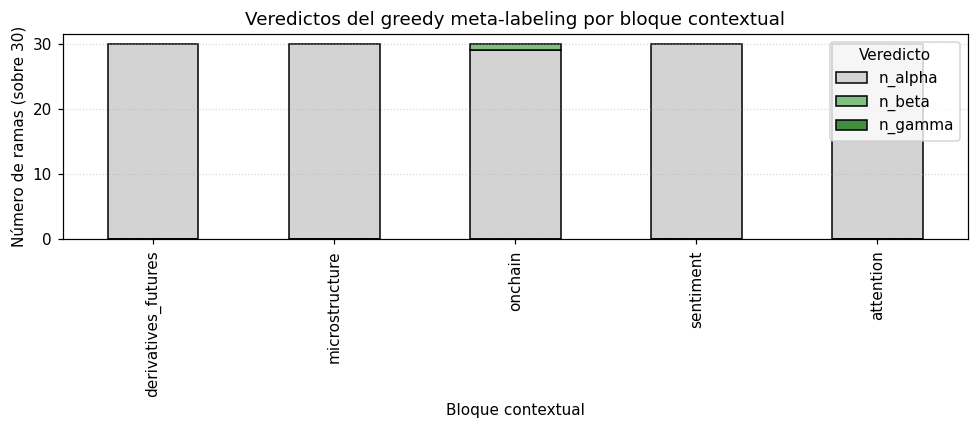

In [29]:
nodes = load_metalabeling_contextual_nodes(REPORT_ROOT, branch_stamp=BRANCH_STAMP)
a_es(nodes).to_csv(FIG_DIR / 'metalabeling_contextual_nodes_raw.csv', index=False)

per_block = (
    nodes.groupby('block')
    .agg(
        n_evaluations=('verdict', 'size'),
        n_alpha=('verdict', lambda s: int((s == 'alpha').sum())),
        n_beta=('verdict', lambda s: int((s == 'beta').sum())),
        n_gamma=('verdict', lambda s: int((s == 'gamma').sum())),
        median_delta_sharpe=('median_delta_sharpe', 'median'),
        median_wilcoxon_p=('wilcoxon_p_value', 'median'),
        median_aggregate_sharpe=('aggregate_sharpe', 'median'),
        median_mean_filter_ratio=('mean_filter_ratio', 'median'),
    )
    .reindex(list(METALABELING_CONTEXTUAL_BLOCKS))
)
a_es(per_block).to_csv(FIG_DIR / 'metalabeling_value_added_by_block.csv')
print('Aportación marginal por bloque contextual')
display_es(per_block)

fig, ax = plt.subplots(figsize=(9, 4))
per_block[['n_alpha', 'n_beta', 'n_gamma']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#d3d3d3', '#7fbf7f', '#3f8f3f'], edgecolor='black',
)
ax.set_title('Veredictos del greedy meta-labeling por bloque contextual')
ax.set_ylabel(f'Número de ramas (sobre {len(winners)})')
ax.set_xlabel('Bloque contextual')
ax.legend(title='Veredicto', loc='upper right')
ax.grid(axis='y', linestyle=':', alpha=0.5)
fig.tight_layout()
fig.savefig(FIG_DIR / 'metalabeling_verdicts_by_block.png')
plt.show()

## 4. Sharpe agregado del nodo raíz (`core_only`) frente al ganador del *greedy*

Diferencia `delta_sharpe = winner - core` por rama. En las ramas cuyo ganador es `core_only` (29/30 en el panel actual) esta diferencia
es por construcción 0; solo aporta señal en aquellas ramas donde el *greedy* aceptó expansión (`beta` o `gamma`).

In [30]:
delta_df = winners.assign(
    delta_winner_minus_core=lambda d: d['winner_aggregate_sharpe'] - d['core_aggregate_sharpe']
).loc[:, [
    'cell_key', 'symbol', 'method', 'family',
    'core_aggregate_sharpe', 'winner_aggregate_sharpe',
    'winner_subset', 'winner_verdict', 'delta_winner_minus_core',
]]
a_es(delta_df).to_csv(FIG_DIR / 'metalabeling_core_vs_winner.csv', index=False)

aggregate_stats = pd.DataFrame({
    'core_sharpe_median': [winners['core_aggregate_sharpe'].median()],
    'core_sharpe_mean': [winners['core_aggregate_sharpe'].mean()],
    'winner_sharpe_median': [winners['winner_aggregate_sharpe'].median()],
    'winner_sharpe_mean': [winners['winner_aggregate_sharpe'].mean()],
    'delta_median': [delta_df['delta_winner_minus_core'].median()],
    'delta_mean': [delta_df['delta_winner_minus_core'].mean()],
    'n_branches_with_delta_gt0': [int((delta_df['delta_winner_minus_core'] > 0).sum())],
    'n_branches_with_delta_eq0': [int((delta_df['delta_winner_minus_core'] == 0).sum())],
})
a_es(aggregate_stats).to_csv(FIG_DIR / 'metalabeling_core_vs_winner_aggregate.csv', index=False)
print('Sharpe core vs. ganador (estadísticas agregadas)')
display_es(aggregate_stats.T.rename(columns={0: 'valor'}))

print('Ramas con delta diferente 0 (greedy expandido)')
display_es(delta_df[delta_df['delta_winner_minus_core'] != 0].sort_values('delta_winner_minus_core', ascending=False))

Sharpe core vs. ganador (estadísticas agregadas)


,valor
core_sharpe_median,0.000234
core_sharpe_mean,0.001398
winner_sharpe_median,0.002134
winner_sharpe_mean,0.002353
delta_median,0.000000
delta_mean,0.000955
n_branches_with_delta_gt0,1.000000
n_branches_with_delta_eq0,29.000000


Ramas con delta diferente 0 (greedy expandido)


,clave_celda,simbolo,metodo,familia,sharpe_agregado_core,sharpe_agregado_ganador,subset_ganador,veredicto_ganador,delta_ganador_menos_core
28,XRPUSDT/triple_barrier/lstm,XRPUSDT,triple_barrier,lstm,-0.001676,0.026987,onchain,beta,0.028664


## 5. Operativa del *meta*: tasa de filtrado y ejecución sobre el primario

Para cada nodo el JSON expone tres métricas operativas del *meta* agregadas a nivel rama:

- `mean_filter_ratio`: fracción media de señales primarias filtradas por el *meta*.
- `mean_meta_executed_ratio_vs_total_test`: fracción media de señales que el *meta* deja pasar al *backtest*.
- `mean_delta_sharpe`: mejora media por *fold* del Sharpe agregado por el *meta* sobre el primario.

Se reportan en formato agregado para el nodo raíz `core_only` (todas las ramas) y para los nodos contextuales
(disgregados por bloque).

Operativa del meta-labeling raíz (core_only) sobre 30 ramas


,valor
mean_filter_ratio_median,0.460100
mean_filter_ratio_p10,0.397927
mean_filter_ratio_p90,0.524380
mean_meta_executed_ratio_median,0.536221
mean_delta_sharpe_median,0.008008
mean_delta_sharpe_mean,0.007422



Operativa del meta-labeling por bloque contextual


,tasa_filtrado_mediana,tasa_ejecutadas_meta_mediana,delta_sharpe_medio_mediana,delta_sharpe_medio_p10,delta_sharpe_medio_p90
bloque,,,,,
derivatives_futures,0.460758,0.536500,0.004159,-0.009270,0.025240
microstructure,0.458915,0.539216,0.004137,-0.014394,0.023804
onchain,0.459073,0.539165,0.010117,-0.008585,0.021871
sentiment,0.456446,0.534524,0.010045,-0.012393,0.024935
attention,0.464019,0.534524,0.010840,-0.005444,0.020925


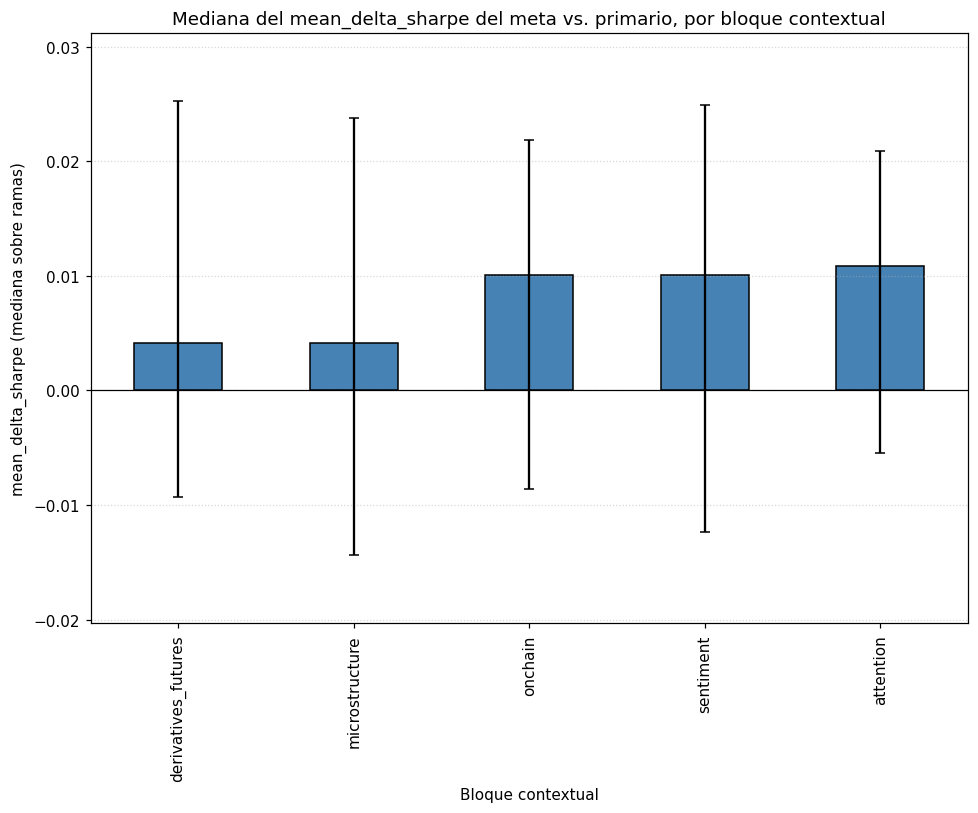

In [31]:
core_meta_stats = pd.DataFrame({
    'mean_filter_ratio_median': [winners['core_mean_filter_ratio'].median()],
    'mean_filter_ratio_p10': [winners['core_mean_filter_ratio'].quantile(0.1)],
    'mean_filter_ratio_p90': [winners['core_mean_filter_ratio'].quantile(0.9)],
    'mean_meta_executed_ratio_median': [winners['core_mean_meta_executed_ratio'].median()],
    'mean_delta_sharpe_median': [winners['core_mean_delta_sharpe'].median()],
    'mean_delta_sharpe_mean': [winners['core_mean_delta_sharpe'].mean()],
})
a_es(core_meta_stats).to_csv(FIG_DIR / 'metalabeling_core_meta_operational_stats.csv', index=False)
print(f'Operativa del meta-labeling raíz (core_only) sobre {len(winners)} ramas')
display_es(core_meta_stats.T.rename(columns={0: 'valor'}))

per_block_meta = (
    nodes.groupby('block')
    .agg(
        mean_filter_ratio_median=('mean_filter_ratio', 'median'),
        mean_meta_executed_ratio_median=('mean_meta_executed_ratio', 'median'),
        mean_delta_sharpe_median=('mean_delta_sharpe', 'median'),
        mean_delta_sharpe_p10=('mean_delta_sharpe', lambda s: s.quantile(0.1)),
        mean_delta_sharpe_p90=('mean_delta_sharpe', lambda s: s.quantile(0.9)),
    )
    .reindex(list(METALABELING_CONTEXTUAL_BLOCKS))
)
a_es(per_block_meta).to_csv(FIG_DIR / 'metalabeling_block_meta_operational_stats.csv')
print('\nOperativa del meta-labeling por bloque contextual')
display_es(per_block_meta)

_err_lo = per_block_meta['mean_delta_sharpe_median'] - per_block_meta['mean_delta_sharpe_p10']
_err_hi = per_block_meta['mean_delta_sharpe_p90'] - per_block_meta['mean_delta_sharpe_median']
_y_min = float((per_block_meta['mean_delta_sharpe_median'] - _err_lo).min())
_y_max = float((per_block_meta['mean_delta_sharpe_median'] + _err_hi).max())
_y_pad = max(0.002, 0.15 * (_y_max - _y_min))

fig, ax = plt.subplots(figsize=(9, 7.5))
per_block_meta['mean_delta_sharpe_median'].plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='black',
    yerr=[_err_lo, _err_hi],
    capsize=3,
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylim(min(0.0, _y_min) - _y_pad, max(0.0, _y_max) + _y_pad)
ax.set_title('Mediana del mean_delta_sharpe del meta vs. primario, por bloque contextual')
ax.set_ylabel('mean_delta_sharpe (mediana sobre ramas)')
ax.set_xlabel('Bloque contextual')
ax.grid(axis='y', linestyle=':', alpha=0.5)
fig.tight_layout()
fig.savefig(FIG_DIR / 'metalabeling_mean_delta_sharpe_by_block.png')
plt.show()

## 6. Dispersión *fold* a *fold* del Sharpe del ganador por rama

Distribución del Sharpe por *fold* del nodo ganador, agrupada por celda `(symbol, method, family)`. Permite leer
la **estabilidad temporal** del *meta* seleccionado por el *greedy* y la magnitud relativa de la dispersión frente
a la mediana, antes de cualquier conclusión económica.

Dispersión por celda (ordenada por mediana descendente)


,clave_celda,n_folds,mediana_sharpe,media_sharpe,desv_std_sharpe,p10_sharpe,p90_sharpe,subset_ganador,veredicto_ganador
23,SOLUSDT/triple_barrier/xgboost,18,0.029537,0.027099,0.064348,-0.037827,0.099376,core_only,root
17,ETHUSDT/triple_barrier/xgboost,28,0.021713,0.003668,0.090702,-0.121881,0.094097,core_only,root
9,BTCUSDT/trend_scanning/xgboost,97,0.015156,0.029233,0.174621,-0.172297,0.218867,core_only,root
24,XRPUSDT/fixed_horizon/lstm,89,0.013943,0.010411,0.132642,-0.153950,0.176962,core_only,root
5,BNBUSDT/triple_barrier/xgboost,29,0.010911,0.012232,0.078745,-0.072415,0.131120,core_only,root
11,BTCUSDT/triple_barrier/xgboost,97,0.010694,0.004855,0.133723,-0.159033,0.192127,core_only,root
15,ETHUSDT/trend_scanning/xgboost,97,0.010576,-0.002106,0.182746,-0.235881,0.210059,core_only,root
3,BNBUSDT/trend_scanning/xgboost,95,0.010277,0.021583,0.196579,-0.233276,0.276535,core_only,root
1,BNBUSDT/fixed_horizon/xgboost,95,0.001921,0.011389,0.128730,-0.137268,0.200397,core_only,root
28,XRPUSDT/triple_barrier/lstm,26,0.001869,0.026987,0.084746,-0.054752,0.124362,onchain,beta


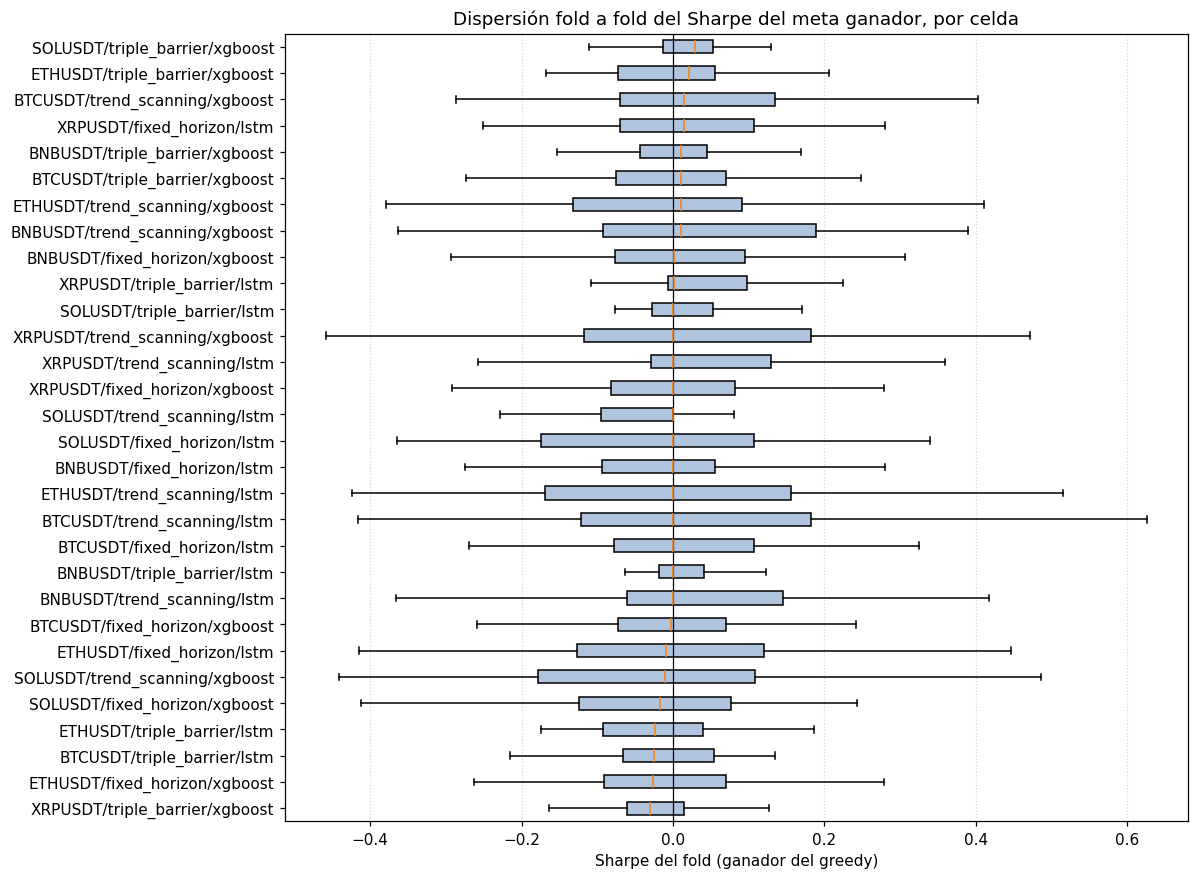

In [32]:
fold_df = load_metalabeling_winner_fold_sharpes(REPORT_ROOT, branch_stamp=BRANCH_STAMP)
a_es(fold_df).to_csv(FIG_DIR / 'metalabeling_winner_fold_sharpes.csv', index=False)

dispersion = (
    fold_df.groupby('cell_key')
    .agg(
        n_folds=('sharpe', 'size'),
        median_sharpe=('sharpe', 'median'),
        mean_sharpe=('sharpe', 'mean'),
        std_sharpe=('sharpe', 'std'),
        p10_sharpe=('sharpe', lambda s: s.quantile(0.1)),
        p90_sharpe=('sharpe', lambda s: s.quantile(0.9)),
    )
    .reset_index()
    .merge(winners[['cell_key', 'winner_subset', 'winner_verdict']], on='cell_key', how='left')
    .sort_values('median_sharpe', ascending=False)
)
a_es(dispersion).to_csv(FIG_DIR / 'metalabeling_winner_fold_dispersion.csv', index=False)
print('Dispersión por celda (ordenada por mediana descendente)')
display_es(dispersion)

ordered = dispersion.sort_values('median_sharpe')['cell_key'].tolist()
fig, ax = plt.subplots(figsize=(11, max(4, 0.27 * len(ordered))))
data = [fold_df.loc[fold_df['cell_key'] == ck, 'sharpe'].values for ck in ordered]
bp = ax.boxplot(data, vert=False, tick_labels=ordered, showfliers=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Sharpe del fold (ganador del greedy)')
ax.set_title('Dispersión fold a fold del Sharpe del meta ganador, por celda')
ax.grid(axis='x', linestyle=':', alpha=0.5)
fig.tight_layout()
fig.savefig(FIG_DIR / 'metalabeling_winner_fold_boxplot.png')
plt.show()

## 7. DSR del campeón meta-greedy (N acumulado Exp1.5 + Exp2-meta)

Esta sección complementa la lectura de Sharpe agregado del greedy meta-labeling con un *Deflated Sharpe Ratio* de **admisibilidad estadística** sobre el campeón de cada rama, **antes** de aplicar el carril 2.5 de riesgo (EVT/CVaR). Replica el contrato del Exp 2 supervisado (`05_resumen_greedy_contextual.ipynb`, sección 7): el greedy eligió por Sharpe; aquí se audita cuántas ramas resistirían un gate `DSR >= 0.95` con la multiplicidad acumulada hasta esta fase.

**N de deflación (solo fases previas al riesgo):** a nivel celda `(symbol, method)` se suman únicamente:

- `n_trials_meta_shortlist`: trials del shortlist meta (Exp1.5).
- `n_trials_meta_greedy`: nodos evaluados en la fase greedy meta (Exp2-meta), agrupando ambas familias (xgboost + lstm) que compitieron en la misma celda.

**No se incluye Exp2.5 meta** (`n_trials_25`): en este punto del pipeline el motor de riesgo aún no se ha aplicado, por lo que sumar esos trials carecería de sentido metodológico. El DSR del carril completo (Exp1.5 + Exp2-meta + Exp2.5) se reporta en `08_resumen_carril_riesgo_meta_labeling_contextual.ipynb` (sección 8).

**Estadísticos OOS del campeón:** `observed_sr`, `n_obs`, asimetría y curtosis desde el `dsr_report` del summary JSON del nodo ganador (`winner_summary_path`). El DSR se calcula con `expected_max_sharpe` y `probabilistic_sharpe_ratio` (`src.validation.dsr`), usando `sr_std` empírico del *pool* de Sharpes intra-celda (shortlist meta + nodos greedy meta).

,simbolo,metodo,familia,subset_ganador,veredicto_ganador,sharpe_observado,n_obs,n_trials_meta_shortlist,n_trials_meta_greedy,n_trials_total,sr_std_intra_celda,sharpe_max_esperado,psr,dsr,dsr_supera_0_95
0,XRPUSDT,trend_scanning,lstm,core_only,root,0.035709,16020,2,12,14,0.010275,0.017863,0.999999,0.990401,True
1,BNBUSDT,trend_scanning,lstm,core_only,root,0.021235,17100,2,12,14,0.008552,0.014867,0.997735,0.802695,False
2,SOLUSDT,triple_barrier,xgboost,core_only,root,0.021197,3240,5,12,17,0.006952,0.012709,0.886069,0.685415,False
3,SOLUSDT,triple_barrier,lstm,core_only,root,0.015279,3240,5,12,17,0.006952,0.012709,0.807692,0.558142,False
4,XRPUSDT,triple_barrier,lstm,onchain,beta,0.022286,4680,6,12,18,0.012731,0.023601,0.936293,0.464164,False
5,BNBUSDT,triple_barrier,xgboost,core_only,root,0.013733,5220,2,12,14,0.009038,0.015713,0.839630,0.443095,False
6,ETHUSDT,triple_barrier,xgboost,core_only,root,0.009944,5040,3,12,15,0.010114,0.017909,0.759886,0.285896,False
7,BNBUSDT,trend_scanning,xgboost,core_only,root,0.009618,17100,2,12,14,0.008552,0.014867,0.895858,0.246133,False
8,BNBUSDT,triple_barrier,lstm,core_only,root,0.006136,5220,2,12,14,0.009038,0.015713,0.671187,0.244564,False
9,XRPUSDT,fixed_horizon,lstm,core_only,root,-0.004027,16020,2,12,14,0.006168,0.010723,0.304816,0.030729,False


Ramas con DSR >= 0.95: 1 / 30
Mediana DSR: 0.0022 | Mediana Sharpe OOS: -0.0068 | Mediana E[max SR]: 0.0182


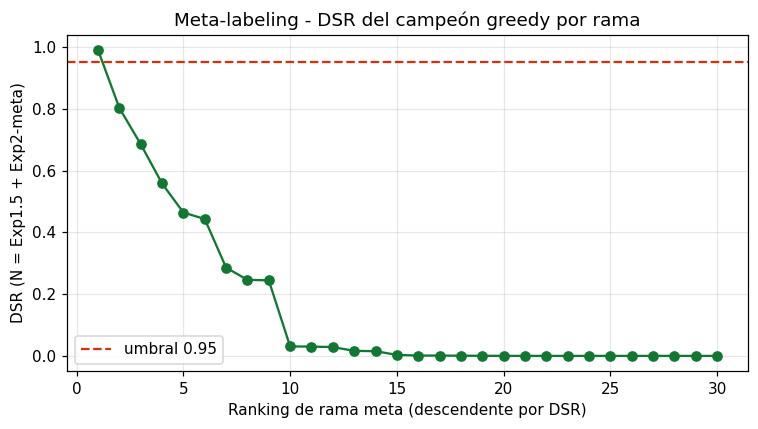

In [33]:
import sys
from pathlib import Path

if 'ROOT' not in globals():
    _root = Path.cwd().resolve()
    while _root != _root.parent and not (_root / 'src').exists():
        _root = _root.parent
    if not (_root / 'src').exists():
        raise FileNotFoundError('No se encontró la raíz del repo (carpeta src/).')
    ROOT = _root
    EVIDENCE_DIR = ROOT / 'evidence_utils'
    if str(EVIDENCE_DIR) not in sys.path:
        sys.path.insert(0, str(EVIDENCE_DIR))
    from phase_summaries import (
        METALABELING_GREEDY_STAMP_DEFAULT,
        collect_meta_greedy_cell_deflators,
        collect_meta_shortlist_cell_deflators,
        load_meta_greedy_winner_oos_from_row,
        load_metalabeling_greedy_winners,
    )
    REPORT_ROOT = ROOT / 'reports' / 'validation' / 'experiments'
    FIG_DIR = ROOT / 'reports' / 'figures' / 'exp_synthesis' / 'metalabeling_contextual_greedy'
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    BRANCH_STAMP = METALABELING_GREEDY_STAMP_DEFAULT
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from IPython.display import display

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.validation.dsr import (
    SharpeStats,
    expected_max_sharpe,
    probabilistic_sharpe_ratio,
)

DSR_UMBRAL = 0.95


def _cell_sr_std(sharpes: list[float]) -> float:
    if len(sharpes) >= 2:
        return max(float(np.std(sharpes, ddof=1)), 1e-6)
    if sharpes:
        return max(abs(sharpes[0]) * 0.1, 1e-6)
    return 1e-6


def _compute_dsr_meta_greedy(
    observed_sr: float,
    n_obs: int,
    skewness: float,
    excess_kurtosis: float,
    n_trials: int,
    sr_std: float,
) -> tuple[float, float, float]:
    stats = SharpeStats(
        observed_sr=float(observed_sr),
        n_obs=int(n_obs),
        skewness=float(skewness),
        excess_kurtosis=float(excess_kurtosis),
    )
    e_max = expected_max_sharpe(max(int(n_trials), 1), sr_std=float(sr_std))
    psr = probabilistic_sharpe_ratio(stats, benchmark_sr=0.0)
    dsr = probabilistic_sharpe_ratio(stats, benchmark_sr=e_max)
    return float(e_max), float(psr), float(dsr)


# Recarga winners
winners = load_metalabeling_greedy_winners(REPORT_ROOT, branch_stamp=BRANCH_STAMP)

meta_shortlist_cells = collect_meta_shortlist_cell_deflators(REPORT_ROOT)
meta_greedy_cells = collect_meta_greedy_cell_deflators(REPORT_ROOT, BRANCH_STAMP)

rows_dsr: list[dict] = []
skipped_no_oos = 0
for _, winner in winners.iterrows():
    symbol = str(winner['symbol']).upper()
    method = str(winner['method'])
    cell_key = (symbol, method)

    sl = meta_shortlist_cells.get(cell_key, {'n_trials': 0, 'sharpes': []})
    gr = meta_greedy_cells.get(cell_key, {'n_nodes': 0, 'sharpes': []})
    n_total = int(sl['n_trials']) + int(gr['n_nodes'])
    sr_std = _cell_sr_std(list(sl['sharpes']) + list(gr['sharpes']))

    oos = load_meta_greedy_winner_oos_from_row(REPORT_ROOT, BRANCH_STAMP, winner)
    if oos is None:
        skipped_no_oos += 1
        continue

    observed_sr = oos['observed_sr']
    n_obs = oos['n_obs']
    if n_obs < 3:
        e_max = psr = dsr = np.nan
    else:
        e_max, psr, dsr = _compute_dsr_meta_greedy(
            observed_sr,
            n_obs,
            oos['skewness'],
            oos['excess_kurtosis'],
            n_total,
            sr_std,
        )

    rows_dsr.append({
        'symbol': symbol,
        'method': method,
        'family': winner['family'],
        'winner_subset': winner['winner_subset'],
        'winner_verdict': winner['winner_verdict'],
        'winner_aggregate_sharpe': float(winner['winner_aggregate_sharpe']),
        'observed_sr': observed_sr,
        'n_obs': n_obs,
        'n_trials_meta_shortlist': int(sl['n_trials']),
        'n_trials_meta_greedy': int(gr['n_nodes']),
        'n_trials_total': n_total,
        'sr_std_intra_celda': sr_std,
        'expected_max_sr': e_max,
        'psr_meta_greedy': psr,
        'dsr_meta_greedy': dsr,
        'dsr_supera_umbral': bool(dsr >= DSR_UMBRAL) if pd.notna(dsr) else False,
    })

dsr_df = pd.DataFrame(rows_dsr)
if dsr_df.empty:
    print(
        'No se pudieron calcular filas DSR. '
        f'Ramas sin OOS resoluble: {skipped_no_oos}/{len(winners)}. '
        'Re-ejecuta la celda de setup (celda 1) y vuelve a lanzar esta seccion.'
    )
else:
    dsr_df = dsr_df.sort_values('dsr_meta_greedy', ascending=False).reset_index(drop=True)

    columnas_dsr_es = {
        'symbol': 'simbolo',
        'method': 'metodo',
        'family': 'familia',
        'winner_subset': 'subset_ganador',
        'winner_verdict': 'veredicto_ganador',
        'winner_aggregate_sharpe': 'sharpe_ganador_agregado',
        'observed_sr': 'sharpe_observado',
        'n_obs': 'n_obs',
        'n_trials_meta_shortlist': 'n_trials_meta_shortlist',
        'n_trials_meta_greedy': 'n_trials_meta_greedy',
        'n_trials_total': 'n_trials_total',
        'sr_std_intra_celda': 'sr_std_intra_celda',
        'expected_max_sr': 'sharpe_max_esperado',
        'psr_meta_greedy': 'psr',
        'dsr_meta_greedy': 'dsr',
        'dsr_supera_umbral': 'dsr_supera_0_95',
    }

    cols_show = [
        'symbol', 'method', 'family', 'winner_subset', 'winner_verdict',
        'observed_sr', 'n_obs',
        'n_trials_meta_shortlist', 'n_trials_meta_greedy', 'n_trials_total',
        'sr_std_intra_celda', 'expected_max_sr', 'psr_meta_greedy',
        'dsr_meta_greedy', 'dsr_supera_umbral',
    ]
    vista = dsr_df[cols_show].rename(columns=columnas_dsr_es)
    vista.to_csv(FIG_DIR / 'metalabeling_dsr_meta_greedy.csv', index=False)
    display(vista.head(20))

    n_ok = int((dsr_df['dsr_meta_greedy'] >= DSR_UMBRAL).sum())
    print(f'Ramas con DSR >= {DSR_UMBRAL:.2f}: {n_ok} / {len(dsr_df)}')
    print(
        f'Mediana DSR: {float(dsr_df["dsr_meta_greedy"].median()):.4f} '
        f'| Mediana Sharpe OOS: {float(dsr_df["observed_sr"].median()):.4f} '
        f'| Mediana E[max SR]: {float(dsr_df["expected_max_sr"].median()):.4f}'
    )

    fig, ax = plt.subplots(figsize=(7.0, 4.0))
    sorted_dsr = dsr_df['dsr_meta_greedy'].dropna().sort_values(ascending=False).to_numpy()
    ax.plot(range(1, len(sorted_dsr) + 1), sorted_dsr, marker='o', color='#117733')
    ax.axhline(DSR_UMBRAL, color='#CC3311', linestyle='--', label=f'umbral {DSR_UMBRAL}')
    ax.set_xlabel('Ranking de rama meta (descendente por DSR)')
    ax.set_ylabel('DSR (N = Exp1.5 + Exp2-meta)')
    ax.set_title('Meta-labeling - DSR del campeón greedy por rama')
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'metalabeling_dsr_meta_greedy_ranking.png')
    plt.show()

## 8. Síntesis ejecutiva

- **Cobertura de campaña:** panel **30/30** ramas con `branch_complete=true`.
- **Decisión del *greedy*:** **29/30** ramas se quedan en `core_only` (`winner_verdict = root`). La única expansión aceptada es `onchain` en `XRPUSDT/triple_barrier/lstm` (veredicto `beta`).
- **Valor añadido contextual:** sobre **150** evaluaciones directas (30 ramas × 5 bloques), el driver rechaza el **99.3 %** de expansiones (**149** `alpha`, **1** `beta`, **0** `gamma`). La excepción puntual coincide con la rama `onchain` arriba; el resto de bloques queda en `alpha` en todo el panel.
- **Operativa del *meta* raíz:** el nodo `core_only` filtra de forma estable el **46.0 %** de las señales primarias en mediana (`p10 = 39.8 %`, `p90 = 52.4 %`) y deja ejecutar un **53.6 %** en mediana. El `mean_delta_sharpe` mediano es `+0.0080` (media `+0.0074`): efecto agregado pequeño, positivo en promedio, pero lejos de sostener una mejora robusta y universal.
- **Dispersión temporal:** la variabilidad *fold* a *fold* del Sharpe del ganador sigue siendo alta en varias celdas, en línea con lo ya observado en Exp 1.5 y Exp 2. La lectura económica de ramas individuales debe mantenerse subordinada al control de multiplicidad y no al Sharpe agregado aislado.
- **DSR pre-riesgo (sección 7):** con `N = Exp1.5 + Exp2-meta` (sin Exp2.5), solo **1/30** campeones superan `DSR >= 0.95` (`XRPUSDT / trend_scanning / lstm / core_only`).

En el estado final del proyecto, este notebook queda acotado al cierre del **Exp2-meta**: documenta si la capa contextual mejora o no al *meta* antes de EVT/CVaR. La evidencia consolidada es negativa para una mejora sistemática; por tanto, el *meta-labeling* contextual se interpreta aquí como un filtro auditable y celda-dependiente, no como un mecanismo universal de ganancia. La evaluación del carril completo con riesgo y sizing se desplaza a `08_resumen_carril_riesgo_meta_labeling_contextual.ipynb`.

**Artefactos persistidos** (todos bajo `reports/figures/exp_synthesis/metalabeling_contextual_greedy/`):

- `metalabeling_winners_raw.csv`
- `metalabeling_branches_by_family.csv`, `metalabeling_branches_by_method.csv`, `metalabeling_branches_by_symbol.csv`
- `metalabeling_winner_subset_counts.csv`, `metalabeling_winner_depth_counts.csv`, `metalabeling_winner_verdict_counts.csv`
- `metalabeling_winner_decision_bars.png`
- `metalabeling_contextual_nodes_raw.csv`, `metalabeling_value_added_by_block.csv`, `metalabeling_verdicts_by_block.png`
- `metalabeling_core_vs_winner.csv`, `metalabeling_core_vs_winner_aggregate.csv`
- `metalabeling_core_meta_operational_stats.csv`, `metalabeling_block_meta_operational_stats.csv`, `metalabeling_mean_delta_sharpe_by_block.png`
- `metalabeling_winner_fold_sharpes.csv`, `metalabeling_winner_fold_dispersion.csv`, `metalabeling_winner_fold_boxplot.png`
- `metalabeling_dsr_meta_greedy.csv`, `metalabeling_dsr_meta_greedy_ranking.png`